# 3-Pulse Mach-Zehnder Interferometer

Demonstrates a $\pi/2 - \pi - \pi/2$ Mach-Zehnder atom interferometer sequence.

Pulse phases: $0$, $\phi$, $4\phi$ respectively, with $\phi$ scanned from $0$ to $2\pi$.


In [26]:
import sys

p = "2026-03-02 LMT sim"
if not any(p in s for s in sys.path):
    sys.path.append(p)

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import version_info as vs

from lmt_simulation import (
    build_mach_zehnder_pulse_sequence,
    calculate_excited_fraction_for_pulse_sequence,
    mach_zehnder_pulse_phase,
)



In [28]:
from scipy import constants

T_FREE = 200e-6  # Free evolution time between pulses

# Realistic rabi freq
T_PI = 45e-6
RABI_FREQ = 1 / (T_PI * 2)
MASS_ATOM = constants.atomic_mass * 87
TRANSITION_WAVELENGTH = 698e-9
# Single-photon recoil frequency: f_r = h / (2 * m * lambda^2)
F_RECOIL = constants.h / (MASS_ATOM * TRANSITION_WAVELENGTH**2)

# Pulse area multiplier: 1.0 = optimal (pi/2 - pi - pi/2), <1 under-rotates, >1 over-rotates
PULSE_AREA_MULTIPLIER = 0.8

DETUNING_HZ = F_RECOIL / 2


phi_values = np.linspace(0, 2 * np.pi, 101)

In [29]:
pulse_sequence = build_mach_zehnder_pulse_sequence(
    detuning_hz=DETUNING_HZ,
    time_between_pulses=T_FREE,
    rabi_frequency=RABI_FREQ,
    pulse_area_multiplier=PULSE_AREA_MULTIPLIER,
    k=+1,
)


def calc_mz_excitation_borde(phi, pulse_sequence, initial_velocity_z=0.0):
    return calculate_excited_fraction_for_pulse_sequence(
        pulse_sequence,
        initial_velocity_z=initial_velocity_z,
        pulse_phase_fn=lambda pulse: mach_zehnder_pulse_phase(pulse, phi),
    )


# Simulate single zero-velocity atom
excitation_fractions = np.array([
    calc_mz_excitation_borde(phi, pulse_sequence=pulse_sequence)
    for phi in phi_values
])


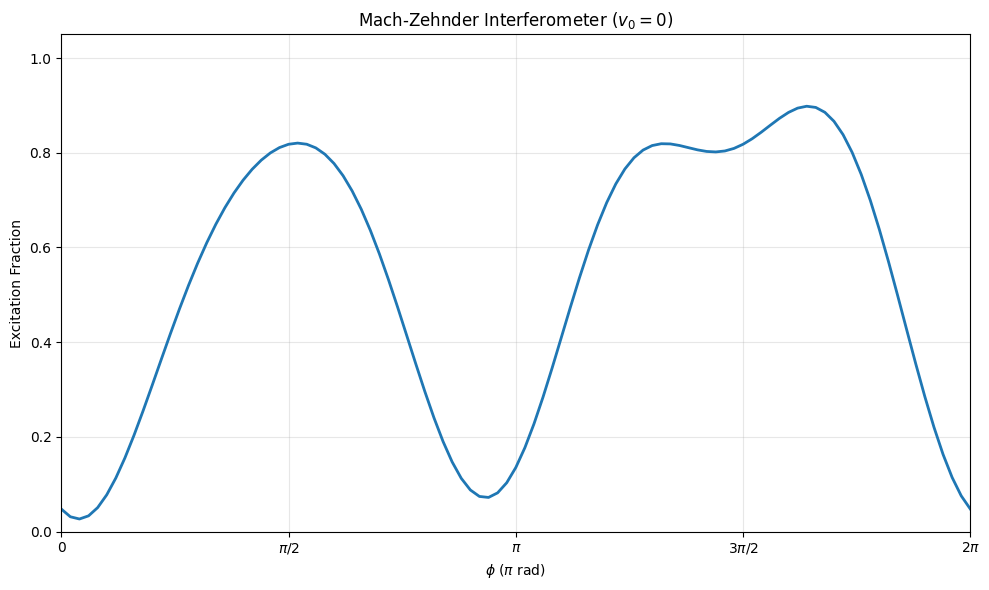

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(phi_values / np.pi, excitation_fractions, color="tab:blue", lw=2)

ax.set_xlabel(r"$\phi$ ($\pi$ rad)")
ax.set_ylabel("Excitation Fraction")
ax.set_title("Mach-Zehnder Interferometer ($v_0 = 0$)")
ax.set_xticks([0, 0.5, 1, 1.5, 2], ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.05)
vs.tag_plot(small=True)
fig.tight_layout()
